In [1]:
!pip install transformers peft datasets scikit-learn pandas -q

In [2]:
!pip install -q torchao --upgrade
import importlib
import peft
importlib.reload(peft)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.7 MB/s eta 0:00:00


<module 'peft' from '/usr/local/lib/python3.12/dist-packages/peft/__init__.py'>

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# load data
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')
y_train_full = pd.read_csv('y_train.csv')
y_test_full = pd.read_csv('y_test.csv')

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain labels:\n", train['label'].value_counts())

GPU available: True
GPU name: Tesla T4

Train shape: (928, 7)
Test shape: (599, 4)

Train labels:
 label
Support general      336
Fileservice          203
Software             125
O365                 124
Active Directory      78
Computer-Services     62
Name: count, dtype: int64


In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# label mapping
label2id = {label: idx for idx, label in enumerate(train['label'].unique())}
id2label = {idx: label for label, idx in label2id.items()}
print("Label mapping:", label2id)

# prepare data
train_texts = train['text_clean'].tolist()
train_labels = [label2id[l] for l in train['label'].tolist()]
test_texts = test['text_clean'].tolist()
test_labels = [label2id[l] for l in test['label'].tolist()]

# tokenizer
model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=256)
    encodings['labels'] = labels
    return Dataset.from_dict(encodings)

train_dataset = tokenize(train_texts, train_labels)
test_dataset = tokenize(test_texts, test_labels)

print("Datasets ready")
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Label mapping: {'Fileservice': 0, 'Support general': 1, 'Software': 2, 'O365': 3, 'Active Directory': 4, 'Computer-Services': 5}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Datasets ready
Train size: 928
Test size: 599


In [8]:
!pip install torchao>=0.16.0 -q

In [9]:
# load base model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

# apply LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 742,662 || all params: 136,071,948 || trainable%: 0.5458


In [10]:
import json

config_data = {
    "id2label": {str(v): k for k, v in label2id.items()},
    "label2id": label2id
}

with open('label_config.json', 'w') as f:
    json.dump(config_data, f, indent=2)

print(json.dumps(config_data, indent=2))

from google.colab import files
files.download('label_config.json')

{
  "id2label": {
    "0": "Fileservice",
    "1": "Support general",
    "2": "Software",
    "3": "O365",
    "4": "Active Directory",
    "5": "Computer-Services"
  },
  "label2id": {
    "Fileservice": 0,
    "Support general": 1,
    "Software": 2,
    "O365": 3,
    "Active Directory": 4,
    "Computer-Services": 5
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
training_args = TrainingArguments(
    output_dir="./lora_model_a",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    learning_rate=2e-4,
    warmup_ratio=0.1,
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.636198,1.409778,0.514190,0.229541
2,1.201302,1.100609,0.559265,0.262100
3,1.032502,0.914189,0.664441,0.543684
4,0.827138,0.842845,0.686144,0.548445
5,0.693242,0.718363,0.727880,0.651206
6,0.632158,0.713270,0.737896,0.657539
7,0.547810,0.669516,0.762938,0.685546
8,0.527901,0.664891,0.769616,0.694420
9,0.511062,0.643087,0.771285,0.695176
10,0.492185,0.639921,0.779633,0.704753


TrainOutput(global_step=580, training_loss=0.808608681580116, metrics={'train_runtime': 202.4385, 'train_samples_per_second': 45.841, 'train_steps_per_second': 2.865, 'total_flos': 625278538874880.0, 'train_loss': 0.808608681580116, 'epoch': 10.0})

                   precision    recall  f1-score   support

      Fileservice       0.88      0.96      0.92       138
  Support general       0.76      0.89      0.82       221
         Software       0.67      0.55      0.60        58
             O365       0.78      0.67      0.72        92
 Active Directory       0.48      0.24      0.32        49
Computer-Services       0.89      0.80      0.85        41

         accuracy                           0.78       599
        macro avg       0.74      0.69      0.70       599
     weighted avg       0.77      0.78      0.77       599



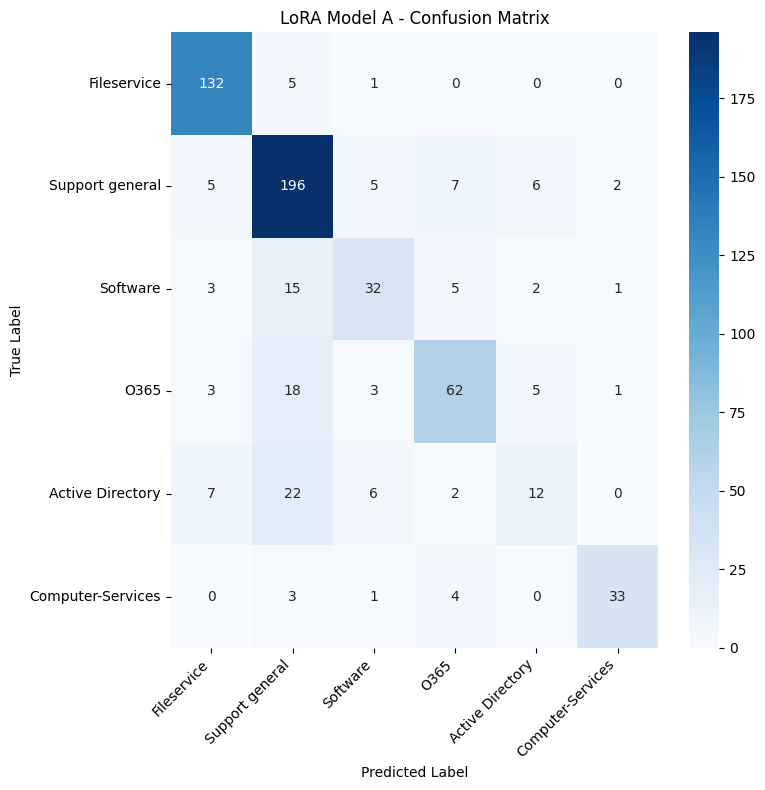

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# get predictions
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# classification report
print(classification_report(true_labels, preds, target_names=list(label2id.keys())))

# confusion matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()))
plt.title('LoRA Model A - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lora_model_a_confusion_matrix.png', dpi=150)
plt.show()

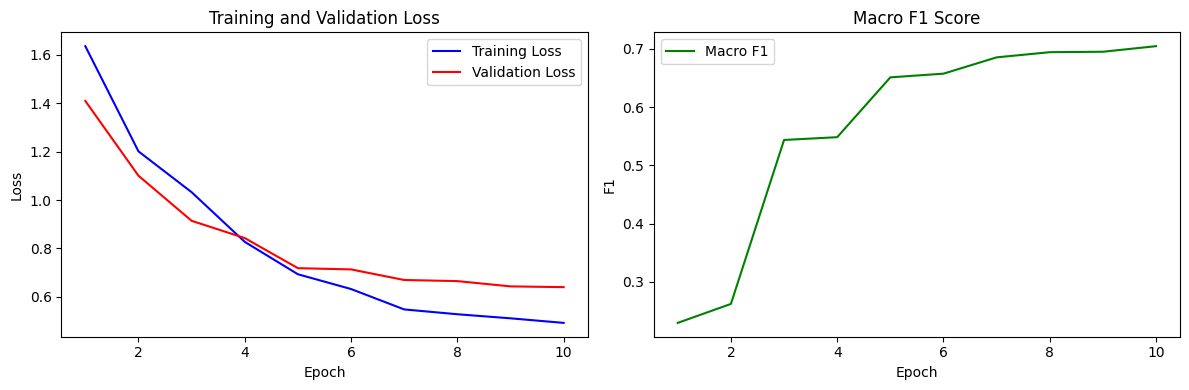

In [ ]:
# training history
epochs = list(range(1, 11))
train_loss = [1.636198, 1.201302, 1.032502, 0.827138, 0.693242, 0.632158, 0.547810, 0.527901, 0.511062, 0.492185]
val_loss = [1.409778, 1.100609, 0.914189, 0.842845, 0.718363, 0.713270, 0.669516, 0.664891, 0.643087, 0.639921]
macro_f1 = [0.229541, 0.262100, 0.543684, 0.548445, 0.651206, 0.657539, 0.685546, 0.694420, 0.695176, 0.704753]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label='Training Loss', color='blue')
ax1.plot(epochs, val_loss, label='Validation Loss', color='red')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, macro_f1, label='Macro F1', color='green')
ax2.set_title('Macro F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()

plt.tight_layout()
plt.savefig('lora_model_a_training_curve.png', dpi=150)
plt.show()

In [ ]:
import shutil

# save adapter
model.save_pretrained("lora_model_a_adapter")
tokenizer.save_pretrained("lora_model_a_adapter")

# zip and download
shutil.make_archive("lora_model_a", 'zip', "lora_model_a_adapter")

from google.colab import files
files.download("lora_model_a.zip")
files.download("lora_model_a_confusion_matrix.png")
files.download("lora_model_a_training_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### MODEL - B (WITH EOL)

In [ ]:
import pandas as pd

# load original data
y_train_full = pd.read_csv('y_train.csv')
X_train_full = pd.read_csv('train_final.csv')
y_test_full = pd.read_csv('y_test.csv')
X_test_full = pd.read_csv('test_final.csv')

# merge
train_b = X_train_full.copy()
train_b['label'] = y_train_full['category_truth']

# keep EOL this time - but deduplicate
train_b = train_b.drop_duplicates(subset='text_clean', keep='first')

print(train_b['label'].value_counts())
print("\nTotal:", len(train_b))

label
Support general      314
Fileservice          313
Software              86
O365                  82
Active Directory      48
Computer-Services     33
EOL                   24
Name: count, dtype: int64

Total: 900


In [ ]:
# check columns first
print("X_test columns:", X_test_full.columns.tolist())
print("y_test columns:", y_test_full.columns.tolist())
print("train_b columns:", train_b.columns.tolist())

# label mapping for 7 classes
label2id_b = {label: idx for idx, label in enumerate(train_b['label'].unique())}
id2label_b = {idx: label for label, idx in label2id_b.items()}
print("\nLabel mapping:", label2id_b)

# merge test data
test_b = X_test_full.copy()
test_b['label'] = y_test_full['category_truth']

# keep only labels that exist in training set
test_b = test_b[test_b['label'].isin(label2id_b.keys())]
print(f"\nTest samples after filtering: {len(test_b)}")
print(test_b['label'].value_counts())

# prepare
train_texts_b = train_b['text_clean'].tolist()
train_labels_b = [label2id_b[l] for l in train_b['label'].tolist()]
test_texts_b = test_b['text_clean'].tolist()
test_labels_b = [label2id_b[l] for l in test_b['label'].tolist()]

print(f"\nTrain: {len(train_texts_b)}, Test: {len(test_texts_b)}")

# tokenize
train_dataset_b = tokenize(train_texts_b, train_labels_b)
test_dataset_b = tokenize(test_texts_b, test_labels_b)
print("Datasets ready")

X_test columns: ['id', 'text', 'label', 'text_clean']
y_test columns: ['id', 'category_truth']
train_b columns: ['id', 'text', 'label', 'text_len', 'word_count', 'lang', 'text_clean']

Label mapping: {'Fileservice': 0, 'Support general': 1, 'Software': 2, 'EOL': 3, 'O365': 4, 'Active Directory': 5, 'Computer-Services': 6}

Test samples after filtering: 599
label
Support general      205
Fileservice          128
O365                  83
EOL                   53
Software              49
Active Directory      43
Computer-Services     38
Name: count, dtype: int64

Train: 900, Test: 599
Datasets ready


In [ ]:
# fresh model for Model B
model_b = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id_b),
    id2label=id2label_b,
    label2id=label2id_b
)

lora_config_b = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

model_b = get_peft_model(model_b, lora_config_b)
model_b.print_trainable_parameters()

training_args_b = TrainingArguments(
    output_dir="./lora_model_b",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    learning_rate=2e-4,
    warmup_steps=50,
    logging_steps=20,
    report_to="none"
)

trainer_b = Trainer(
    model=model_b,
    args=training_args_b,
    train_dataset=train_dataset_b,
    eval_dataset=test_dataset_b,
    compute_metrics=compute_metrics
)

trainer_b.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 743,431 || all params: 136,073,486 || trainable%: 0.5463


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.650200,1.864230,0.320534,0.091410
2,1.557603,1.858533,0.262104,0.096409
3,1.549681,1.913145,0.280467,0.098597
4,1.496851,1.883204,0.278798,0.102788
5,1.551566,1.894255,0.313856,0.098690
6,1.532307,1.882524,0.300501,0.106778
7,1.410719,1.919497,0.303840,0.097759
8,1.421657,1.926761,0.297162,0.104588
9,1.359150,1.969357,0.275459,0.100869
10,1.357073,1.964057,0.270451,0.098094


TrainOutput(global_step=570, training_loss=1.4847245283294142, metrics={'train_runtime': 202.2863, 'train_samples_per_second': 44.491, 'train_steps_per_second': 2.818, 'total_flos': 606433637376000.0, 'train_loss': 1.4847245283294142, 'epoch': 10.0})

In [ ]:
predictions_b = trainer_b.predict(test_dataset_b)
preds_b = np.argmax(predictions_b.predictions, axis=-1)
true_labels_b = predictions_b.label_ids

print(classification_report(true_labels_b, preds_b,
      target_names=list(label2id_b.keys())))

                   precision    recall  f1-score   support

      Fileservice       0.22      0.45      0.30       128
  Support general       0.36      0.60      0.45       205
         Software       0.00      0.00      0.00        49
              EOL       0.00      0.00      0.00        53
             O365       0.00      0.00      0.00        83
 Active Directory       0.00      0.00      0.00        43
Computer-Services       0.00      0.00      0.00        38

         accuracy                           0.30       599
        macro avg       0.08      0.15      0.11       599
     weighted avg       0.17      0.30      0.22       599



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

      Fileservice       0.22      0.45      0.30       128
  Support general       0.36      0.60      0.45       205
         Software       0.00      0.00      0.00        49
              EOL       0.00      0.00      0.00        53
             O365       0.00      0.00      0.00        83
 Active Directory       0.00      0.00      0.00        43
Computer-Services       0.00      0.00      0.00        38

         accuracy                           0.30       599
        macro avg       0.08      0.15      0.11       599
     weighted avg       0.17      0.30      0.22       599



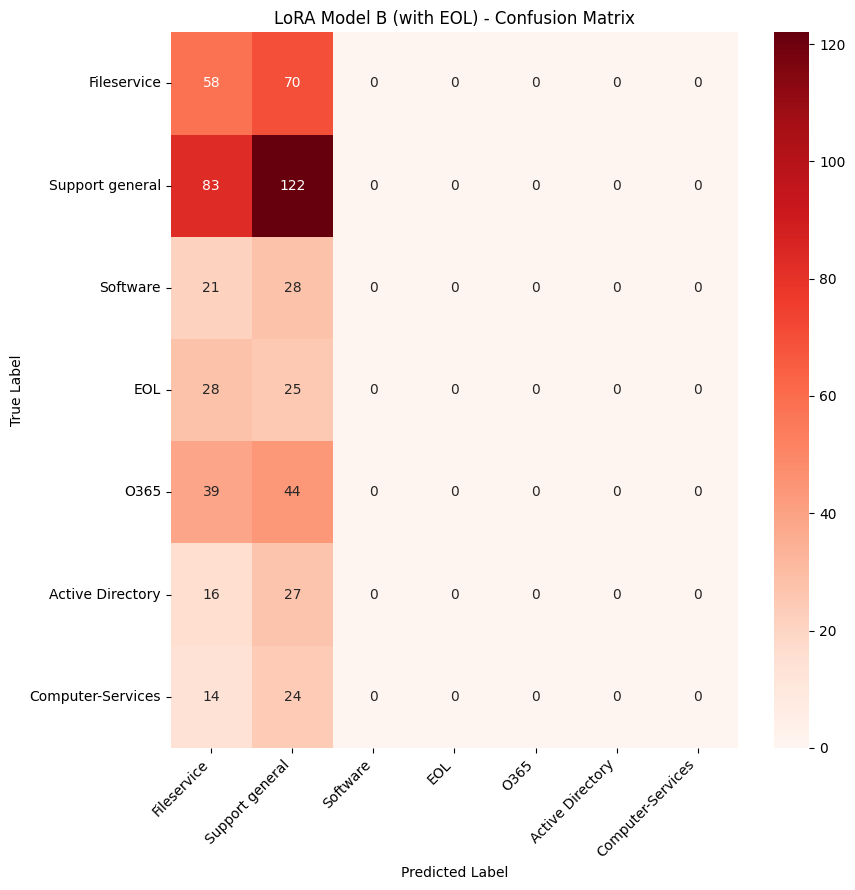

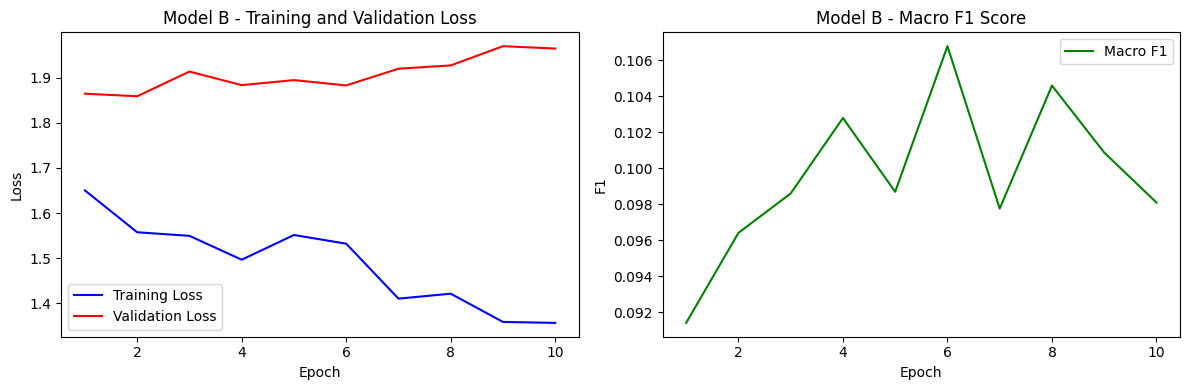

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# classification report
predictions_b = trainer_b.predict(test_dataset_b)
preds_b = np.argmax(predictions_b.predictions, axis=-1)
true_labels_b = predictions_b.label_ids

print(classification_report(true_labels_b, preds_b,
      target_names=list(label2id_b.keys())))

# confusion matrix
cm_b = confusion_matrix(true_labels_b, preds_b)
plt.figure(figsize=(9, 9))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds',
            xticklabels=list(label2id_b.keys()),
            yticklabels=list(label2id_b.keys()))
plt.title('LoRA Model B (with EOL) - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lora_model_b_confusion_matrix.png', dpi=150)
plt.show()

# training curve
epochs = list(range(1, 11))
train_loss_b = [1.650200, 1.557603, 1.549681, 1.496851, 1.551566, 1.532307, 1.410719, 1.421657, 1.359150, 1.357073]
val_loss_b = [1.864230, 1.858533, 1.913145, 1.883204, 1.894255, 1.882524, 1.919497, 1.926761, 1.969357, 1.964057]
macro_f1_b = [0.091410, 0.096409, 0.098597, 0.102788, 0.098690, 0.106778, 0.097759, 0.104588, 0.100869, 0.098094]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss_b, label='Training Loss', color='blue')
ax1.plot(epochs, val_loss_b, label='Validation Loss', color='red')
ax1.set_title('Model B - Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, macro_f1_b, label='Macro F1', color='green')
ax2.set_title('Model B - Macro F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()

plt.tight_layout()
plt.savefig('lora_model_b_training_curve.png', dpi=150)
plt.show()

# download everything
from google.colab import files
files.download('lora_model_b_confusion_matrix.png')
files.download('lora_model_b_training_curve.png')